# MOF CO2 Adsorption Prediction

A supervised regression model predicting CO2 uptake at 0.5 bar for hypothetical
MOFs, using structural descriptors (pore geometry, void fraction, surface area)
and metal type as features.

Data source: hMOF database, accessed via [MOFX-DB](https://mof.tech.northwestern.edu/)
through the `mofdb_client` Python package.

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mofdb_client import fetch
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

random.seed(42)

## Data Collection

The hMOF database (~138,000 hypothetical MOFs) is organized in large ID-based
blocks by metal type, not randomly. An initial naive sample (first N matches) or
even a systematic interval sample returned structures that were nearly 100% Zn.
A full scan of the filtered stream confirmed the true population: Zn (81,090),
Cu (33,128), V (6,634), Zr (4,838).

To get a chemically balanced sample, we use **reservoir sampling**: a single pass
over the full filtered API stream that maintains a random, balanced subset of
500 MOFs per metal type, extracting the CO2 uptake at 0.5 bar (the pressure grid
is fixed and identical across all MOFs: 0.01, 0.05, 0.1, 0.5, 2.5 bar) in the same
pass — avoiding a separate, much slower per-MOF re-query step.

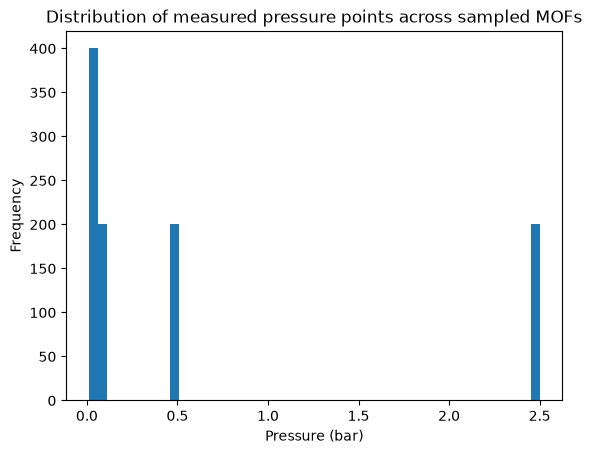

Min: 0.01, Max: 2.5


In [1]:
from mofdb_client import fetch
import matplotlib.pyplot as plt

all_pressures = []
count = 0

for mof in fetch(vf_min=0.3, vf_max=0.7, database='hMOF'):
    for iso in mof.isotherms:
        if iso.adsorbates[0].formula == 'CO2':
            pressures = [point.pressure for point in iso.isotherm_data]
            all_pressures.extend(pressures)
    count += 1
    if count >= 200:   # check a sample of 200 MOFs, not the whole database yet
        break

plt.hist(all_pressures, bins=50)
plt.xlabel("Pressure (bar)")
plt.ylabel("Frequency")
plt.title("Distribution of measured pressure points across sampled MOFs")
plt.show()

print(f"Min: {min(all_pressures)}, Max: {max(all_pressures)}")

In [4]:
SAMPLES_PER_METAL = 500
known_metals = ['Zn', 'Cu', 'V', 'Zr']
target_pressure = 0.5

reservoirs = {m: [] for m in known_metals}
seen_counts = {m: 0 for m in known_metals}

scanned = 0
for mof in fetch(vf_min=0.1, vf_max=0.9, database='hMOF'):
    scanned += 1
    if scanned % 10000 == 0:
        print(f"Scanned {scanned}...")

    elements = [str(e) for e in mof.elements]
    metals_here = [el for el in elements if el in known_metals]
    if not metals_here:
        continue
    metal = metals_here[0]

    co2_uptake = None
    for iso in mof.isotherms:
        if iso.adsorbates[0].formula == 'CO2':
            for point in iso.isotherm_data:
                if point.pressure == target_pressure:
                    co2_uptake = point.species_data[0].adsorption
                    break
            break
    if co2_uptake is None:
        continue

    record = {
        "name": mof.name,
        "lcd": mof.lcd,
        "pld": mof.pld,
        "void_fraction": mof.void_fraction,
        "surface_area_m2g": mof.surface_area_m2g,
        "elements": ",".join(elements),
        "co2_uptake_0.5bar": co2_uptake,
    }

    seen_counts[metal] += 1
    reservoir = reservoirs[metal]
    if len(reservoir) < SAMPLES_PER_METAL:
        reservoir.append(record)
    else:
        j = random.randint(0, seen_counts[metal] - 1)
        if j < SAMPLES_PER_METAL:
            reservoir[j] = record

records = [r for m in known_metals for r in reservoirs[m]]
df = pd.DataFrame(records)
print(f"Final dataset shape: {df.shape}")
df.head()

Scanned 10000...
Scanned 20000...
Scanned 30000...
Scanned 40000...
Scanned 50000...
Scanned 60000...
Scanned 70000...
Scanned 80000...
Scanned 90000...
Scanned 100000...
Scanned 110000...
Scanned 120000...
Final dataset shape: (2000, 7)


,name,lcd,pld,void_fraction,surface_area_m2g,elements,co2_uptake_0.5bar
0,hMOF-5009118,4.25,2.75,0.295180,304.2,"Zn,O,C,H",1.01004
1,hMOF-10433,8.75,7.75,0.707055,2599.5,"Zn,O,C,H",2.73858
2,hMOF-5016073,13.75,12.25,0.797393,5024.3,"Zn,O,C,H,N",1.08728
3,hMOF-5011354,9.25,6.75,0.811598,5322.4,"Zn,O,C,H",1.64886
4,hMOF-4665,5.75,4.25,0.523469,1813.9,"Zn,O,C,H",2.77147


In [5]:
df.to_csv("mof_co2_dataset.csv", index=False)
print("Saved.")

Saved.


## Exploratory Data Analysis

Before modeling, we examine the target distribution, check data quality, and
look at early structure–property relationships.

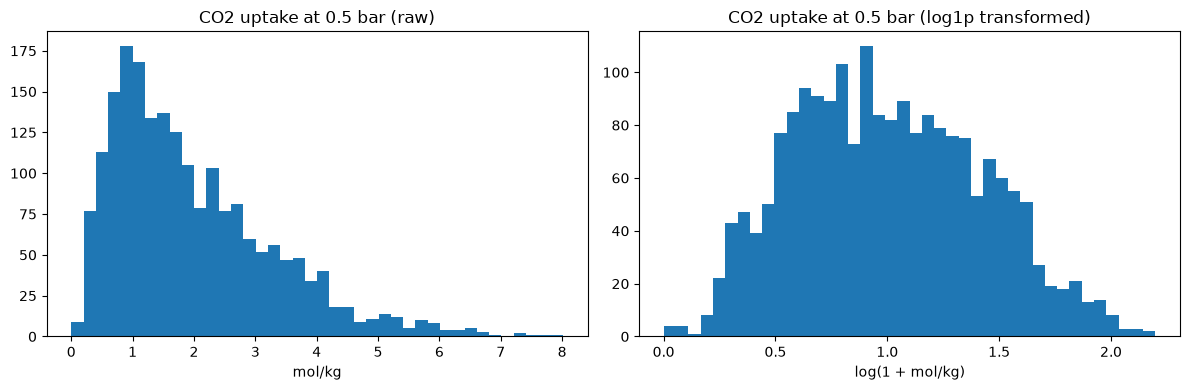

Rows with surface_area_m2g == 0: 8


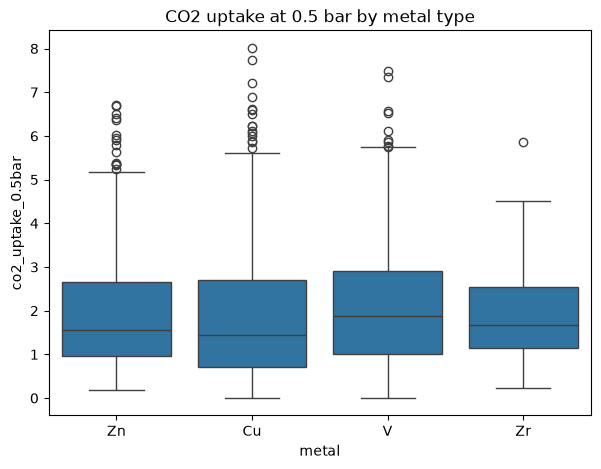

       count      mean       std       min       25%       50%       75%  \
metal                                                                      
Cu     500.0  1.914796  1.556302  0.010345  0.719089  1.435720  2.704065   
V      500.0  2.142844  1.384486  0.000931  1.010215  1.875580  2.902035   
Zn     500.0  1.968125  1.322976  0.172916  0.951477  1.561455  2.654008   
Zr     500.0  1.903538  0.927571  0.239399  1.152807  1.680775  2.531595   

           max  
metal           
Cu     8.01288  
V      7.47664  
Zn     6.69762  
Zr     5.87180  


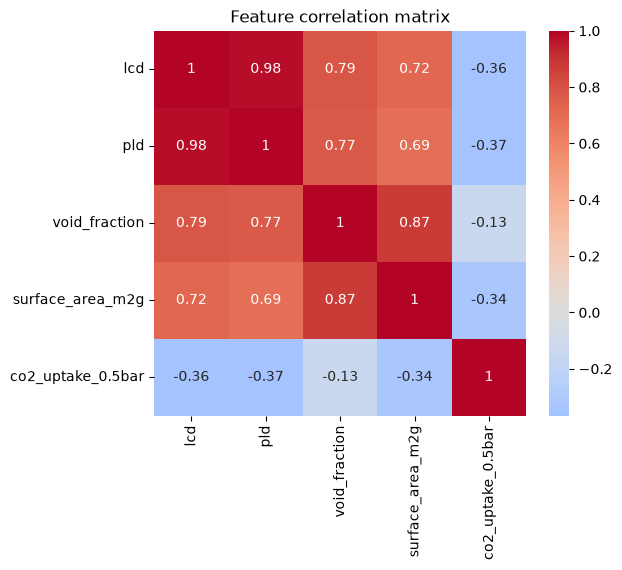

In [6]:
df['metal'] = df['elements'].apply(
    lambda e: next((el for el in e.split(',') if el in ['Zn', 'Cu', 'V', 'Zr']), None)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['co2_uptake_0.5bar'], bins=40)
axes[0].set_title("CO2 uptake at 0.5 bar (raw)")
axes[0].set_xlabel("mol/kg")

axes[1].hist(np.log1p(df['co2_uptake_0.5bar']), bins=40)
axes[1].set_title("CO2 uptake at 0.5 bar (log1p transformed)")
axes[1].set_xlabel("log(1 + mol/kg)")
plt.tight_layout()
plt.show()

print(f"Rows with surface_area_m2g == 0: {(df['surface_area_m2g'] == 0).sum()}")

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='metal', y='co2_uptake_0.5bar')
plt.title("CO2 uptake at 0.5 bar by metal type")
plt.show()
print(df.groupby('metal')['co2_uptake_0.5bar'].describe())

feature_cols_corr = ['lcd', 'pld', 'void_fraction', 'surface_area_m2g', 'co2_uptake_0.5bar']
corr = df[feature_cols_corr].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Feature correlation matrix")
plt.show()

### EDA Findings

- **Target distribution:** right-skewed; `log1p` transform produces a much more
  symmetric distribution. The model will be trained on `log1p(co2_uptake_0.5bar)`.
- **Data quality:** 18/2000 rows (0.9%) have `surface_area_m2g == 0` — physically
  implausible outliers, dropped before modeling.
- **CO2 uptake by metal:** mild differences between metals (V highest mean,
  Cu lowest), but within-group standard deviation (~1.0–1.5 mol/kg) far exceeds
  the between-group spread (~0.3–0.4 mol/kg) — metal identity alone is a weak
  predictor.
- **Feature correlations:** `lcd` and `pld` are almost perfectly correlated
  (r = 0.97), indicating multicollinearity. All structural descriptors are
  *negatively* correlated with uptake at 0.5 bar — consistent with pore-filling
  behavior dominating at lower pressures (smaller pores → stronger confinement
  and adsorption potential), while larger-pore MOFs are expected to express their
  capacity advantage more clearly at higher pressures.

## Feature Engineering & Train/Test Split

- Drop rows with zero surface area
- Log-transform the target
- One-hot encode metal type (nominal categorical, no ordinal relationship)
- Engineer `pore_constriction` (`lcd - pld`) to address `lcd`/`pld` collinearity
  while keeping both original features for the model to weigh

In [7]:
df_clean = df[df['surface_area_m2g'] > 0].copy()

df_clean['log_co2_uptake'] = np.log1p(df_clean['co2_uptake_0.5bar'])

metal_dummies = pd.get_dummies(df_clean['metal'], prefix='metal')
df_clean = pd.concat([df_clean, metal_dummies], axis=1)

df_clean['pore_constriction'] = df_clean['lcd'] - df_clean['pld']

feature_cols = ['lcd', 'pld', 'void_fraction', 'surface_area_m2g',
                 'pore_constriction'] + list(metal_dummies.columns)

X = df_clean[feature_cols]
y = df_clean['log_co2_uptake']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_train_original = np.expm1(y_train)
y_test_original = np.expm1(y_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1593, 9), Test: (399, 9)


## Baseline Model

A default Random Forest, as a starting point before any tuning.

In [8]:
rf_baseline = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)

y_pred_train = np.expm1(rf_baseline.predict(X_train))
y_pred_test = np.expm1(rf_baseline.predict(X_test))

print(f"Train R²: {r2_score(y_train_original, y_pred_train):.3f}")
print(f"Test R²:  {r2_score(y_test_original, y_pred_test):.3f}")
print(f"Test MAE: {mean_absolute_error(y_test_original, y_pred_test):.3f} mol/kg")

Train R²: 0.920
Test R²:  0.414
Test MAE: 0.704 mol/kg


### Diagnosing the Gap

Train R² (0.920) is substantially higher than test R² (0.551), indicating
overfitting rather than a fundamentally unlearnable problem. As a sanity check,
a dummy regressor (predicting the mean for every sample) gives R² ≈ -0.05,
confirming the model is learning real signal, just not generalizing well yet.

In [9]:
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
y_pred_dummy = np.expm1(dummy.predict(X_test))

print(f"Dummy (mean) R²: {r2_score(y_test_original, y_pred_dummy):.3f}")
print(f"Baseline RF R²:  {r2_score(y_test_original, y_pred_test):.3f}")

Dummy (mean) R²: -0.051
Baseline RF R²:  0.414


## Regularized Model

Constraining tree depth and minimum samples per split/leaf to reduce overfitting.

In [10]:
rf_regularized = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1
)
rf_regularized.fit(X_train, y_train)

y_pred_train_reg = np.expm1(rf_regularized.predict(X_train))
y_pred_test_reg = np.expm1(rf_regularized.predict(X_test))

print(f"Train R²: {r2_score(y_train_original, y_pred_train_reg):.3f}")
print(f"Test R²:  {r2_score(y_test_original, y_pred_test_reg):.3f}")
print(f"Test MAE: {mean_absolute_error(y_test_original, y_pred_test_reg):.3f} mol/kg")

Train R²: 0.695
Test R²:  0.425
Test MAE: 0.693 mol/kg


### Note on reproducibility
The mofdb-client API stream order is not guaranteed to be fully deterministic
across requests, so reservoir sampling may select a slightly different subset
of MOFs on repeated runs even with a fixed random seed. The exact dataset used
for this analysis is saved as `mof_co2_dataset.csv` to ensure reproducible results.

In [11]:
from sklearn.model_selection import cross_val_score, KFold

def evaluate_with_cv(model, X, y, cv_folds=5):
    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
    r2_scores = cross_val_score(model, X, y, cv=kf, scoring='r2')
    return r2_scores

configs = {
    "baseline (no limits)": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "max_depth=10": RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    "max_depth=6": RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1),
    "max_depth=10, min_leaf=5": RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=5, random_state=42, n_jobs=-1),
    "max_depth=6, min_leaf=10": RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=10, random_state=42, n_jobs=-1),
}

for name, model in configs.items():
    scores = evaluate_with_cv(model, X_train, y_train)
    print(f"{name}: mean R² = {scores.mean():.3f} (+/- {scores.std():.3f})")

baseline (no limits): mean R² = 0.525 (+/- 0.050)
max_depth=10: mean R² = 0.528 (+/- 0.040)
max_depth=6: mean R² = 0.493 (+/- 0.022)
max_depth=10, min_leaf=5: mean R² = 0.528 (+/- 0.038)
max_depth=6, min_leaf=10: mean R² = 0.487 (+/- 0.023)


In [12]:
final_model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
final_model.fit(X_train, y_train)

y_pred_test = np.expm1(final_model.predict(X_test))
print(f"Final Test R²:  {r2_score(y_test_original, y_pred_test):.3f}")
print(f"Final Test MAE: {mean_absolute_error(y_test_original, y_pred_test):.3f} mol/kg")

Final Test R²:  0.428
Final Test MAE: 0.694 mol/kg


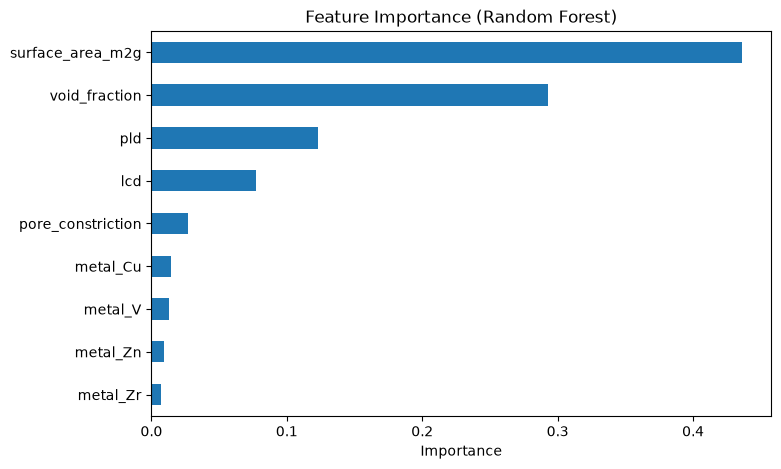

surface_area_m2g     0.436052
void_fraction        0.292853
pld                  0.123250
lcd                  0.076954
pore_constriction    0.026889
metal_Cu             0.014233
metal_V              0.013072
metal_Zn             0.009439
metal_Zr             0.007259
dtype: float64


In [13]:
importances = pd.Series(final_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

print(importances)

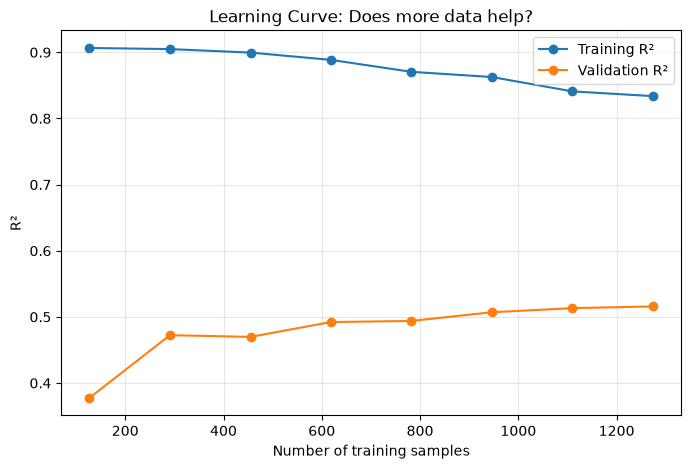

In [14]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5,
    scoring='r2',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', label='Training R²')
plt.plot(train_sizes, val_mean, 'o-', label='Validation R²')
plt.xlabel('Number of training samples')
plt.ylabel('R²')
plt.title('Learning Curve: Does more data help?')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [15]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

variants = {
    "all features (current)": feature_cols,
    "without pore_constriction": [c for c in feature_cols if c != 'pore_constriction'],
    "without metal dummies": [c for c in feature_cols if not c.startswith('metal_')],
    "without lcd (keep pld only)": [c for c in feature_cols if c != 'lcd'],
    "without pld (keep lcd only)": [c for c in feature_cols if c != 'pld'],
    "geometric only (no metal)": ['lcd', 'pld', 'void_fraction', 'surface_area_m2g'],
}

model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)

for name, cols in variants.items():
    scores = cross_val_score(model, X_train[cols], y_train, cv=kf, scoring='r2')
    print(f"{name}: mean R² = {scores.mean():.3f} (+/- {scores.std():.3f})")

all features (current): mean R² = 0.528 (+/- 0.040)
without pore_constriction: mean R² = 0.529 (+/- 0.040)
without metal dummies: mean R² = 0.521 (+/- 0.039)
without lcd (keep pld only): mean R² = 0.515 (+/- 0.041)
without pld (keep lcd only): mean R² = 0.530 (+/- 0.037)
geometric only (no metal): mean R² = 0.519 (+/- 0.037)


### Final feature set decision

The systematic comparison above shows no feature subset meaningfully
outperforms the full set — every variant falls within about ±0.01 R² of
the baseline, well inside the cross-validation standard deviation. The
final model keeps all engineered features, making the feature importance
analysis below directly interpretable against every candidate feature.

### Multi-output regression

In [23]:
import pandas as pd
import time
from mofdb_client import fetch

target_pressures = [0.01, 0.05, 0.1, 0.5, 2.5]
selected_names = df['name'].tolist()

records = []
failed_names = []
processed = 0

for name in selected_names:
    success = False
    for attempt in range(3):
        try:
            for mof in fetch(name=name):
                uptakes = {}
                for iso in mof.isotherms:
                    if iso.adsorbates[0].formula == 'CO2':
                        for point in iso.isotherm_data:
                            if point.pressure in target_pressures:
                                uptakes[point.pressure] = point.species_data[0].adsorption
                        break

                if len(uptakes) != 5:
                    break

                records.append({
                    "name": mof.name,
                    "lcd": mof.lcd,
                    "pld": mof.pld,
                    "void_fraction": mof.void_fraction,
                    "surface_area_m2g": mof.surface_area_m2g,
                    "elements": ",".join(str(e) for e in mof.elements),
                    "uptake_0.01": uptakes[0.01],
                    "uptake_0.05": uptakes[0.05],
                    "uptake_0.1": uptakes[0.1],
                    "uptake_0.5": uptakes[0.5],
                    "uptake_2.5": uptakes[2.5],
                })
                break
            success = True
            break
        except Exception as e:
            wait = 2 ** attempt
            print(f"Error on {name} (attempt {attempt+1}): {e}. Retrying in {wait}s...")
            time.sleep(wait)

    if not success:
        failed_names.append(name)

    processed += 1
    if processed % 200 == 0:
        print(f"Processed {processed}/{len(selected_names)}")
        pd.DataFrame(records).to_csv("mof_co2_multipressure_dataset_partial.csv", index=False)

df_multi = pd.DataFrame(records)
df_multi.to_csv("mof_co2_multipressure_dataset.csv", index=False)
print(f"Final shape: {df_multi.shape}")
print(f"Failed after retries: {len(failed_names)}")

Processed 200/2000
Processed 400/2000
Processed 600/2000
Processed 800/2000
Processed 1000/2000
Processed 1200/2000
Processed 1400/2000
Processed 1600/2000
Processed 1800/2000
Processed 2000/2000
Final shape: (2000, 11)
Failed after retries: 0


### Pressure-dependent model performance

Training separate targets for all 5 measured pressure points reveals a clear
trend: model R² increases monotonically with pressure (0.33 at 0.01 bar → 0.55
at 2.5 bar). This is consistent with the physical picture that low-pressure
adsorption is governed by adsorbate-surface interaction strength (sensitive to
metal chemistry and functional groups not captured in this feature set), while
high-pressure adsorption approaches saturation and is better explained by raw
geometric capacity (pore volume, surface area) — exactly the features this
model has access to.

In [24]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

df_multi_clean = df_multi[df_multi['surface_area_m2g'] > 0].copy()

df_multi_clean['metal'] = df_multi_clean['elements'].apply(
    lambda e: next((el for el in e.split(',') if el in ['Zn', 'Cu', 'V', 'Zr']), None)
)
metal_dummies_multi = pd.get_dummies(df_multi_clean['metal'], prefix='metal')
df_multi_clean = pd.concat([df_multi_clean, metal_dummies_multi], axis=1)

# log-transform all 5 pressure targets
pressure_cols = ['uptake_0.01', 'uptake_0.05', 'uptake_0.1', 'uptake_0.5', 'uptake_2.5']
for col in pressure_cols:
    df_multi_clean[f'log_{col}'] = np.log1p(df_multi_clean[col])

log_target_cols = [f'log_{c}' for c in pressure_cols]

feature_cols_multi = ['lcd', 'pld', 'void_fraction', 'surface_area_m2g'] + list(metal_dummies_multi.columns)

X_multi = df_multi_clean[feature_cols_multi]
y_multi = df_multi_clean[log_target_cols]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)
print(f"Train: {X_train_m.shape}, Test: {X_test_m.shape}")
print(f"Targets: {log_target_cols}")

Train: (1593, 8), Test: (399, 8)
Targets: ['log_uptake_0.01', 'log_uptake_0.05', 'log_uptake_0.1', 'log_uptake_0.5', 'log_uptake_2.5']


In [25]:
rf_multi = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_multi.fit(X_train_m, y_train_m)   # y_train_m has 5 columns — sklearn handles this natively for RandomForestRegressor

y_pred_m = rf_multi.predict(X_test_m)  # shape: (n_samples, 5)

# evaluate each pressure point separately
for i, col in enumerate(pressure_cols):
    y_true = np.expm1(y_test_m.iloc[:, i])
    y_pred = np.expm1(y_pred_m[:, i])
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{col}: R² = {r2:.3f}, MAE = {mae:.3f} mol/kg")

uptake_0.01: R² = 0.328, MAE = 0.119 mol/kg
uptake_0.05: R² = 0.358, MAE = 0.266 mol/kg
uptake_0.1: R² = 0.378, MAE = 0.359 mol/kg
uptake_0.5: R² = 0.426, MAE = 0.694 mol/kg
uptake_2.5: R² = 0.545, MAE = 1.120 mol/kg


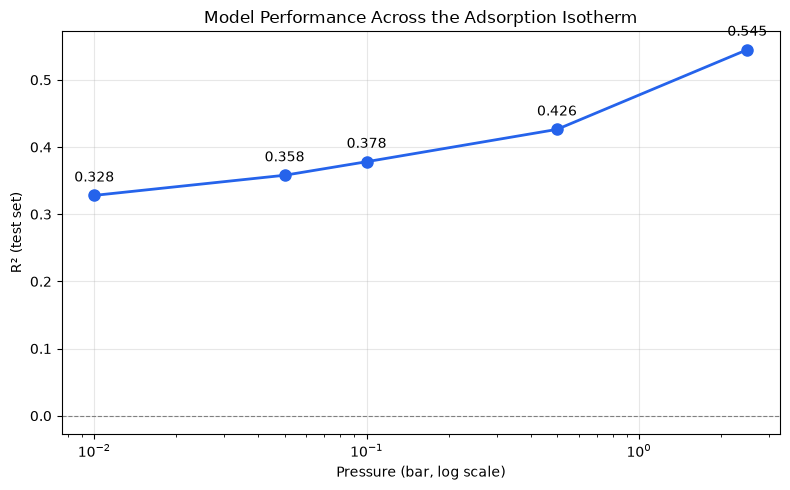

In [26]:
import matplotlib.pyplot as plt

pressures = [0.01, 0.05, 0.1, 0.5, 2.5]
r2_scores = []

for i, col in enumerate(pressure_cols):
    y_true = np.expm1(y_test_m.iloc[:, i])
    y_pred = np.expm1(y_pred_m[:, i])
    r2_scores.append(r2_score(y_true, y_pred))

plt.figure(figsize=(8, 5))
plt.plot(pressures, r2_scores, 'o-', linewidth=2, markersize=8, color='#2563eb')
plt.xscale('log')
plt.xlabel('Pressure (bar, log scale)')
plt.ylabel('R² (test set)')
plt.title('Model Performance Across the Adsorption Isotherm')
plt.grid(alpha=0.3)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.8)

for p, r2 in zip(pressures, r2_scores):
    plt.annotate(f'{r2:.3f}', (p, r2), textcoords="offset points", xytext=(0, 10), ha='center')

plt.tight_layout()
plt.show()

### Residual Analysis


In [27]:
residuals = y_test_original - y_pred_test
worst_predictions = pd.DataFrame({
    'name': df_clean.loc[X_test.index, 'name'],
    'metal': df_clean.loc[X_test.index, 'metal'],
    'actual': y_test_original,
    'predicted': y_pred_test,
    'error': residuals
}).sort_values('error', key=abs, ascending=False)

print(worst_predictions.head(10))

              name metal    actual  predicted     error
1274  hMOF-6003867     V  6.103000   1.514663  4.588337
598   hMOF-5071904    Cu  7.741770   3.298188  4.443582
1319  hMOF-6005018     V  5.610190   1.204141  4.406049
759     hMOF-37085    Cu  5.611030   1.357465  4.253565
60    hMOF-5035971    Zn  5.234760   2.087472  3.147288
455   hMOF-5058662    Zn  5.388230   2.284881  3.103349
988   hMOF-5060146    Cu  0.695172   3.595632 -2.900460
990     hMOF-34318    Cu  1.364320   4.062847 -2.698527
126   hMOF-5049448    Zn  6.409860   3.747164  2.662696
714   hMOF-5058808    Cu  4.861980   2.308283  2.553697


In [29]:
worst_names = worst_predictions.head(10)['name'].tolist()
worst_details = df_clean[df_clean['name'].isin(worst_names)][
    ['name', 'metal', 'lcd', 'pld', 'void_fraction', 'surface_area_m2g', 'co2_uptake_0.5bar']
]

# compare to overall dataset averages for context
print("Worst-predicted MOFs:")
print(worst_details.sort_values('co2_uptake_0.5bar', ascending=False))

print("\nDataset averages for reference:")
print(df_clean[['lcd', 'pld', 'void_fraction', 'surface_area_m2g']].mean())

Worst-predicted MOFs:
              name metal    lcd    pld  void_fraction  surface_area_m2g  \
598   hMOF-5071904    Cu   5.25   4.25       0.684339            2795.0   
126   hMOF-5049448    Zn   5.75   4.25       0.711268            2846.0   
1274  hMOF-6003867     V   9.75   8.75       0.695380            3236.7   
759     hMOF-37085    Cu   9.25   8.25       0.748754            2500.4   
1319  hMOF-6005018     V  11.75  11.25       0.726875            2902.1   
455   hMOF-5058662    Zn   8.25   7.25       0.776829            2737.0   
60    hMOF-5035971    Zn   6.25   5.25       0.652002            2772.2   
714   hMOF-5058808    Cu   8.25   7.25       0.764333            2420.8   
990     hMOF-34318    Cu   7.25   5.25       0.726878            2223.2   
988   hMOF-5060146    Cu   4.75   3.25       0.461235             861.7   

      co2_uptake_0.5bar  
598            7.741770  
126            6.409860  
1274           6.103000  
759            5.611030  
1319           5.61019

In [30]:
all_predictions = pd.DataFrame({
    'metal': df_clean.loc[X_test.index, 'metal'],
    'actual': y_test_original,
    'predicted': y_pred_test,
})
all_predictions['abs_error'] = (all_predictions['actual'] - all_predictions['predicted']).abs()

print(all_predictions.groupby('metal')['abs_error'].agg(['mean', 'std', 'max']))

           mean       std       max
metal                              
Cu     0.717578  0.816826  4.443582
V      0.799171  0.749155  4.588337
Zn     0.756871  0.686794  3.147288
Zr     0.504503  0.428912  1.730957


### Where the model fails

Residual analysis shows the model's largest errors are systematically
underpredictions for geometrically strong MOFs (above-average surface area and
void fraction) whose actual CO2 uptake exceeds what their geometry alone would
predict. This effect is most pronounced for V- and Zn-based structures and
weakest for Zr, which is consistent with Zr's known coordination stability in
MOF chemistry (e.g., the UiO-66 family) versus the more variable oxidation-state
chemistry of vanadium. This points to metal-specific electronic/coordination
effects, not captured by geometric descriptors alone, as a likely source of
the model's remaining error.

## Summary

This project set out to predict MOF CO2 uptake from structural descriptors,
and ended up telling two stories rather than one: a data-quality story (the
hMOF database's hidden metal-based batching, and the sampling fix required to
address it) and a model-interpretation story (a ~0.52 R² ceiling that, through
learning curves, feature-subset comparisons, and residual analysis, was traced
to missing chemical information rather than a fixable modeling choice).

**Key findings:**
- Structural descriptors (surface area, void fraction) explain the majority
  of predictable variance; metal identity among Zn/Cu/V/Zr contributes
  minimally at 0.5 bar.
- Model reliability increases with pressure, consistent with a shift from
  interaction-driven to capacity-driven adsorption.
- Residual analysis points to metal-specific coordination chemistry (open
  metal sites, oxidation-state variability) as the most likely source of
  remaining error, information this feature set cannot see.

See the project README for the full write-up, limitations, and planned v2
directions (richer structural/chemical features via `pymatgen`).